In [62]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [63]:
# STEP 1: LOAD AND EXPLORE RAW DATA

# Load the messy healthcare data
raw_healthcare_data = pd.read_csv('healthcare_messy_data.csv')

# Create reference to cleaned version for validation
#reference_clean_data = pd.read_csv('healthcare_cleaned.csv')

In [64]:
# Heathcare data dimensions
print(f"Total patient records (rows): {raw_healthcare_data.shape[0]}")
print(f"Total clinical features (columns): {raw_healthcare_data.shape[1]}")

# Getting the first 5 patients
print(raw_healthcare_data.head())

# Data type of columns in Heathcare data
column_data_types = raw_healthcare_data.dtypes
print(column_data_types)

Total patient records (rows): 1000
Total clinical features (columns): 10
       Patient Name  Age  Gender      Condition Medication     Visit Date  \
0        david lee    25   Other  Heart Disease  METFORMIN     01/15/2020   
1      emily davis   NaN    Male       Diabetes       NONE  April 5, 2018   
2   laura martinez    35   Other         Asthma  METFORMIN     2019.12.01   
3   michael wilson   NaN    Male       Diabetes  ALBUTEROL     01/15/2020   
4        david lee   NaN  Female         Asthma       NONE     2020/02/20   

  Blood Pressure  Cholesterol               Email  Phone Number  
0         140/90        200.0   name@hospital.org  555-555-5555  
1         120/80        200.0                 NaN           NaN  
2         110/70        160.0  contact@domain.com           NaN  
3         110/70          NaN   name@hospital.org  555-555-5555  
4         110/70        180.0                 NaN                
Patient Name          str
Age                   str
Gender          

In [65]:
# Missing values assessment
print("MISSING VALUES COUNT PER COLUMN")
missing_values_per_column = raw_healthcare_data.isnull().sum()
print(missing_values_per_column[missing_values_per_column > 0])

# Statistical summary
print("STATISTICAL SUMMARY OF NUMERICAL FEATURES")
numerical_summary_stats = raw_healthcare_data.describe()
print(numerical_summary_stats)

# Duplicate check
duplicate_records_count = raw_healthcare_data.duplicated().sum()
print(f"\nDuplicate patient records found: {duplicate_records_count}")

MISSING VALUES COUNT PER COLUMN
Age               159
Condition         206
Blood Pressure    166
Cholesterol       231
Email             384
Phone Number      179
dtype: int64
STATISTICAL SUMMARY OF NUMERICAL FEATURES
       Cholesterol
count    769.00000
mean     189.23277
std       22.28039
min      160.00000
25%      160.00000
50%      180.00000
75%      200.00000
max      220.00000

Duplicate patient records found: 0


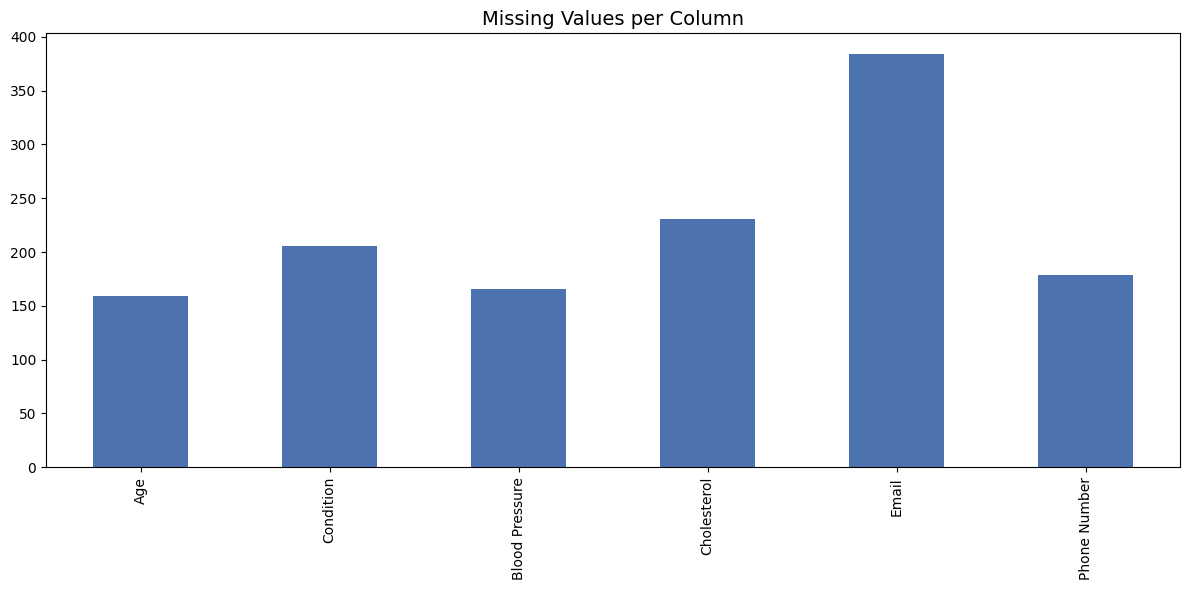

In [66]:
#Bar chart of missing values
plt.figure(figsize=(12, 6))
missing_values_per_column[missing_values_per_column > 0].plot(kind='bar', color='#4C72B0')
plt.title('Missing Values per Column', fontsize=14)
plt.tight_layout()
plt.savefig('missing_values_bar.png', dpi=100)
plt.show()

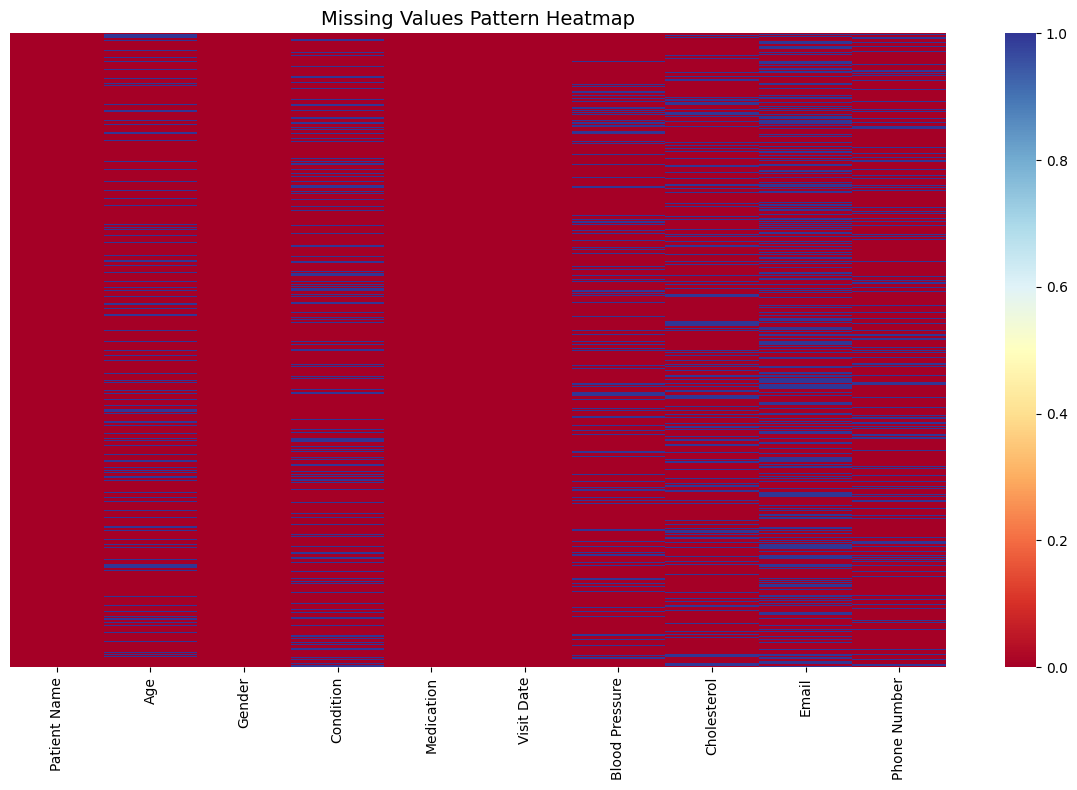

In [67]:
# Heatmap showing missing value patterns - CORRECT VERSION
plt.figure(figsize=(12, 8))
sns.heatmap(raw_healthcare_data.isnull(), cmap='RdYlBu', yticklabels=False, cbar=True)
plt.title('Missing Values Pattern Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('missing_values_heatmap.png', dpi=100)
plt.show()

In [ ]:
# STEP 2: HANDLING MISSING VALUES

# Creating copy for cleaning
cleaned_healthcare_data = raw_healthcare_data.copy()

# Separate numerical and categorical columns
numerical_columns = cleaned_healthcare_data.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = cleaned_healthcare_data.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical columns to process: {numerical_columns}")
print(f"Categorical columns to process: {categorical_columns}")

In [69]:
# Force fill ALL missing values
for col in cleaned_healthcare_data.columns:
    if cleaned_healthcare_data[col].dtype in ['int64', 'float64']:
        cleaned_healthcare_data[col] = cleaned_healthcare_data[col].fillna(cleaned_healthcare_data[col].median())
    else:
        cleaned_healthcare_data[col] = cleaned_healthcare_data[col].fillna(cleaned_healthcare_data[col].mode()[0] if len(cleaned_healthcare_data[col].mode()) > 0 else 'Unknown')

print(f"Final missing values: {cleaned_healthcare_data.isnull().sum().sum()}")

Final missing values: 0


In [70]:
# Verify no missing values remain
remaining_missing = cleaned_healthcare_data.isnull().sum().sum()
print(f"\n✓ Total missing values after imputation: {remaining_missing}")


✓ Total missing values after imputation: 0


In [71]:
# STEP 3: REMOVE DUPLICATE RECORDS

# Identify duplicates before removal
duplicates_before_removal = cleaned_healthcare_data.duplicated().sum()
print(f"Duplicate records identified: {duplicates_before_removal}")

# Remove duplicate rows
cleaned_healthcare_data = cleaned_healthcare_data.drop_duplicates()


# Verify removal
duplicates_after_removal = cleaned_healthcare_data.duplicated().sum()
print(f"Duplicate records after removal: {duplicates_after_removal}")
print(f"✓ Removed {duplicates_before_removal} duplicate patient records")
print(f"✓ Unique patient records remaining: {cleaned_healthcare_data.shape[0]}")

Duplicate records identified: 0
Duplicate records after removal: 0
✓ Removed 0 duplicate patient records
✓ Unique patient records remaining: 1000


In [72]:
# Standardize gender values
if 'Gender' in cleaned_healthcare_data.columns:
    gender_mapping = {
        'M': 'M', 'Male': 'M', 'MALE': 'M', 'male': 'M',
        'F': 'F', 'Female': 'F', 'FEMALE': 'F', 'female': 'F'
    }
    cleaned_healthcare_data['Gender_Standardized'] = cleaned_healthcare_data['Gender'].map(gender_mapping)
    cleaned_healthcare_data.drop('Gender', axis=1, inplace=True)

In [73]:
# Fill missing gender values with 'Unknown'
cleaned_healthcare_data['Gender_Standardized'] = cleaned_healthcare_data['Gender_Standardized'].fillna('Unknown')

In [74]:
# Create cleaning log dictionary (FIX #1)
cleaning_log = {
    'duplicates_removed': duplicates_before_removal
}

In [75]:
print(f"Rows: {raw_healthcare_data.shape[0]} → {cleaned_healthcare_data.shape[0]}")
print(f"Missing Values: {raw_healthcare_data.isnull().sum().sum()} → {cleaned_healthcare_data.isnull().sum().sum()}")
print(f"Duplicates Removed: {cleaning_log['duplicates_removed']}")
print("\n Data cleaning completed successfully!")

Rows: 1000 → 1000
Missing Values: 1325 → 0
Duplicates Removed: 0

 Data cleaning completed successfully!
